Found 84 images belonging to 17 classes.
Found 13 images belonging to 17 classes.


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_50 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 38, 38, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_20 (UpSampling2D) │ (None, 76, 76, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 76, 76, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_21 (UpSampling2D) │ (None, 152, 152, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 152, 152, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - loss: 0.0840 - val_loss: 0.1055
Epoch 2/12
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - loss: 0.0705 - val_loss: 0.0779
Epoch 3/12
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - loss: 0.0513 - val_loss: 0.0365
Epoch 4/12
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 0.0234 - val_loss: 0.0208
Epoch 5/12
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - loss: 0.0179 - val_loss: 0.0176
Epoch 6/12
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - loss: 0.0191 - val_loss: 0.0217
Epoch 7/12
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 0.0200 - val_loss: 0.0152
Epoch 8/12
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 0.0147 - val_loss: 0.0115
Epoch 9/12
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 0.0116 - val_loss: 0.0113
Epoch 10/12
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - loss: 0.0104 - val_loss: 0.0114
Epoch 11/12
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 0.0099 - val_loss: 0.0109
Epoch 12/12
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 0.0092 - val_loss: 0.0104

Reconstruction RMSE: 0

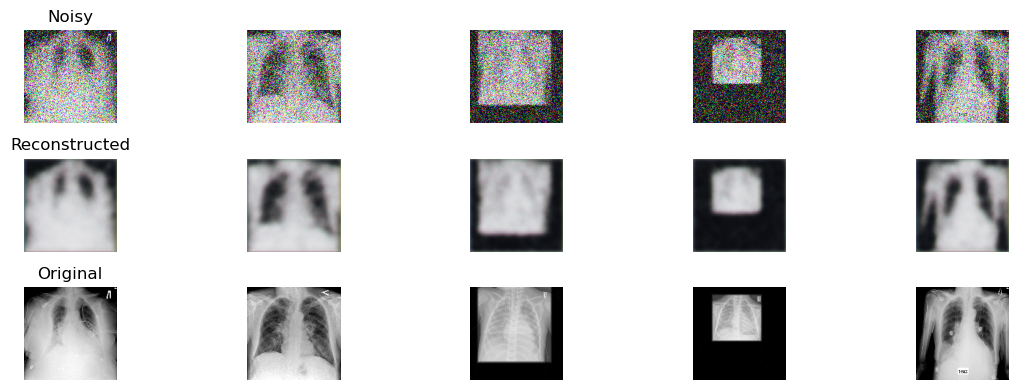

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# Path to dataset 

Path_to_dataset = r"C:\Users\rohan\CW2_Datasets\Dataset2\files"


ImageSize = (152, 152)
batch_size = 40
epochs = 12
noise_level = 0.5


ImageLoader = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2
)

ImageTrainer = ImageLoader.flow_from_directory(
    Path_to_dataset,
    target_size=ImageSize,
    batch_size=batch_size,
    class_mode=None,          
    subset="training"
)

Validation_data = ImageLoader.flow_from_directory(
    Path_to_dataset,
    target_size=ImageSize,
    batch_size=batch_size,
    class_mode=None,
    subset="validation"
)

# Adding noise to image, so we can train the model to denoise the image.
def adding_Noise(images):
    noise = noise_level * np.random.normal(0, 1, images.shape)
    noisy_images = images + noise
    return np.clip(noisy_images, 0.0, 1.0)


autoencoder = models.Sequential()


autoencoder.add(layers.Input(shape=(152, 152, 3)))


autoencoder.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same"))
autoencoder.add(layers.MaxPooling2D((2, 2), padding="same"))

autoencoder.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
autoencoder.add(layers.MaxPooling2D((2, 2), padding="same"))


autoencoder.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
autoencoder.add(layers.UpSampling2D((2, 2)))

autoencoder.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same"))
autoencoder.add(layers.UpSampling2D((2, 2)))


autoencoder.add(layers.Conv2D(3, (3, 3), activation="sigmoid", padding="same"))


autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()


def Noise_Generator(generator):
    while True:
        clean_batch = next(generator)
        noisy_batch = adding_Noise(clean_batch)
        yield noisy_batch, clean_batch


# Training the autoencoder

autoencoder.fit(
    Noise_Generator(ImageTrainer),
    steps_per_epoch=len(ImageTrainer),
    validation_data=Noise_Generator(Validation_data),
    validation_steps=len(Validation_data),
    epochs=epochs
)


Clean = next(Validation_data)
Noisy = adding_Noise(Clean)

reconstructed = autoencoder.predict(Noisy, verbose=0)


rmse = np.sqrt(np.mean((Clean - reconstructed) ** 2))
print("\nReconstruction RMSE:", rmse)


# showing Noisy vs Reconstructed vs Original example

num_examples = 5
plt.figure(figsize=(12, 4))

for i in range(num_examples):
    # Noisy image
    plt.subplot(3, num_examples, i + 1)
    plt.imshow(Noisy[i])
    plt.axis("off")
    if i == 0:
        plt.title("Noisy")

    # Reconstructed image
    plt.subplot(3, num_examples, i + 1 + num_examples)
    plt.imshow(reconstructed[i])
    plt.axis("off")
    if i == 0:
        plt.title("Reconstructed")

    # Original image
    plt.subplot(3, num_examples, i + 1 + 2 * num_examples)
    plt.imshow(Clean[i])
    plt.axis("off")
    if i == 0:
        plt.title("Original")

plt.tight_layout()
plt.show()
